# Coffee Roasting in Tensorflow

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras import Sequential

In [3]:
def load_coffee_data():
    np.random.seed(2)
    X = np.random.rand(400,2)
    X[:,0] = X[:,0] * (285-150) + 150   # temperature 150-285
    X[:,1] = X[:,1] * 4 + 11.5          # duration 11.5-15.5
    Y = np.zeros(len(X))
    for i in range(len(X)):
        t,d = X[i]
        y = -3/(260-175)*t + 21
        if (t > 175 and t < 260 and d > 12 and d < 15 and d <= y):
            Y[i] = 1
    return X, Y.reshape(-1,1) 

X, Y = load_coffee_data()
print(X.shape, Y.shape)

(400, 2) (400, 1)


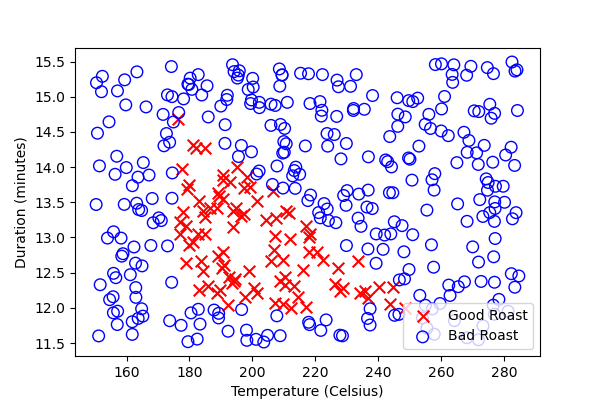

In [4]:
def plt_roast(X, Y):
    Y = Y.reshape(-1,)  #reshap into flat 1d 
    pos = Y == 1
    neg = Y == 0
    fig, ax = plt.subplots(1,1,figsize=(6,4))
    ax.scatter(X[pos,0], X[pos,1], marker='x', s=70, c='red', label="Good Roast")
    ax.scatter(X[neg,0], X[neg,1], marker='o', s=70, facecolors='none', edgecolors='blue', label="Bad Roast")
    ax.set_xlabel("Temperature (Celsius)")
    ax.set_ylabel("Duration (minutes)")
    ax.legend()
    plt.savefig("coffee_roast_data.png")
    plt.close()
    from IPython.display import Image
    return Image("coffee_roast_data.png")

plt_roast(X, Y)

In [5]:
print(f"Temperature Max, Min pre normalization: {np.max(X[:,0]):0.2f}, {np.min(X[:,0]):0.2f}")
print(f"Duration    Max, Min pre normalization: {np.max(X[:,1]):0.2f}, {np.min(X[:,1]):0.2f}")

norm_l = tf.keras.layers.Normalization(axis=-1) #normlization , axis=-1 normalize each feature independentaly
norm_l.adapt(X) #scan and caluculate values but does not apply norm
Xn = norm_l(X) #actually applyig normlization 

print(f"Temperature Max, Min post normalization: {np.max(Xn[:,0]):0.2f}, {np.min(Xn[:,0]):0.2f}")
print(f"Duration    Max, Min post normalization: {np.max(Xn[:,1]):0.2f}, {np.min(Xn[:,1]):0.2f}")

Temperature Max, Min pre normalization: 284.77, 150.34
Duration    Max, Min pre normalization: 15.49, 11.51
Temperature Max, Min post normalization: 1.82, -1.73
Duration    Max, Min post normalization: 1.74, -1.72


In [6]:
#defining model and layers

tf.random.set_seed(1234)
model = Sequential(
[
    tf.keras.Input(shape=(2,)),
    Dense(units=3,activation='sigmoid',name='layer_1'),
    Dense(units=1,activation='sigmoid',name='layer_2')
    
])

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ layer_1 (Dense)                      │ (None, 3)                   │               9 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer_2 (Dense)                      │ (None, 1)                   │               4 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
L1_num_params = 2 * 3 + 3
L2_num_params = 3 * 1 + 1
print("L1 params = ", L1_num_params, ", L2 params = ", L2_num_params)

L1 params =  9 , L2 params =  4


In [9]:
W1,b1 = model.get_layer('layer_1').get_weights()
W2,b2 = model.get_layer('layer_2').get_weights()
print(f"W1{W1.shape}:\n", W1, f"\nb1{b1.shape}:", b1)
print(f"W2{W2.shape}:\n", W2, f"\nb2{b2.shape}:", b2)

W1(2, 3):
 [[-0.08026958  0.8554921  -0.8892119 ]
 [-0.6600007   0.36030817 -0.6664758 ]] 
b1(3,): [0. 0. 0.]
W2(3, 1):
 [[ 1.0747043]
 [ 0.5185683]
 [-1.0401162]] 
b2(1,): [0.]


In [10]:
Xn.shape

TensorShape([400, 2])

#### For tensorflow , this data set is small as big required , so scalling data

In [11]:
Xt = np.tile(Xn,(1000,1)) #tile fucntion to make copy of Xn , 1000 times row repeating and 1 times column
Yt = np.tile(Y,(1000,1))
print(Xt.shape,Yt.shape)

(400000, 2) (400000, 1)


In [12]:
#fucntion to tell the rules for model

model.compile(           
    loss = tf.keras.losses.BinaryCrossentropy(),          #loss function for logistic regression
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),   #telling learning rate  
)

#training model

model.fit(
    Xt,Yt,
    epochs=10,     #tensorflow works in baches , so epochs tell that works in how many numbers of baches
)



Epoch 1/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - loss: 0.2305
Epoch 2/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 45s 4ms/step - loss: 0.1964
Epoch 3/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - loss: 0.1878
Epoch 4/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 43s 3ms/step - loss: 0.0370
Epoch 5/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 43s 3ms/step - loss: 0.0175
Epoch 6/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - loss: 0.0136
Epoch 7/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 43s 3ms/step - loss: 0.0112
Epoch 8/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 43s 3ms/step - loss: 0.0095
Epoch 9/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 43s 3ms/step - loss: 0.0081
Epoch 10/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 45s 4ms/step - loss: 0.0071


In [13]:
W1,b1 = model.get_layer('layer_1').get_weights()
W2,b2 = model.get_layer('layer_2').get_weights()
print("W1:\n", W1, "\nb1:", b1)
print("W2:\n", W2, "\nb2:", b2)

W1:
 [[ 15.962436    25.47775     -0.06154648]
 [  0.21170464  21.418749   -11.165078  ]] 
b1: [ 16.651945    1.1686172 -14.943862 ]
W2:
 [[ 30.729807]
 [-70.41959 ]
 [-41.01243 ]] 
b2: [-13.856462]


In [14]:
W1 = np.array([                    
    [-8.94,  0.29, 12.89],         #rows= neurons and columns= number of features
    [-0.17, -7.34, 10.79]])
b1 = np.array([-9.87, -9.28, 1.01])
W2 = np.array([
    [-31.38],
    [-27.86],
    [-32.79]])
b2 = np.array([15.54])

model.get_layer("layer_1").set_weights([W1,b1])
model.get_layer("layer_2").set_weights([W2,b2])

In [15]:
W1, b1 = model.get_layer("layer_1").get_weights()
W2, b2 = model.get_layer("layer_2").get_weights()
print("W1:\n", W1, "\nb1:", b1)
print("W2:\n", W2, "\nb2:", b2)

W1:
 [[-8.94  0.29 12.89]
 [-0.17 -7.34 10.79]] 
b1: [-9.87 -9.28  1.01]
W2:
 [[-31.38]
 [-27.86]
 [-32.79]] 
b2: [15.54]


In [17]:
X_test = np.array([
    [200,13.9],
    [200,17]
])
X_testn = norm_l(X_test)
predictions = model.predict(X_testn)     #prediction
print("predictions = \n",predictions)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
predictions = 
 [[9.7205293e-01]
 [3.0964269e-08]]


### Threshold decision
Convert the model's probability output into a final 0 or 1 decision using a 0.5 threshold.

In [20]:
yhat = (predictions >=0.5).astype(int)
print(f'decisions = \n{yhat}')

decisions = 
[[1]
 [0]]


### Layer functions
Examine what each neuron in layer1 learned by plotting its output across the full range of temperature and duration values.

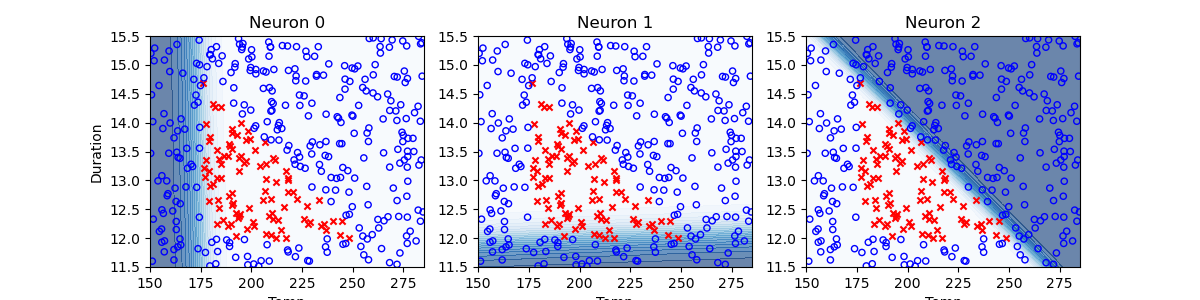

In [22]:
def plt_layer(X, Y, W1, b1, norm_l):
    fig, axes = plt.subplots(1, 3, figsize=(12,3))
    t = np.linspace(150, 285, 50)
    d = np.linspace(11.5, 15.5, 50)
    T, D = np.meshgrid(t, d)
    grid = np.c_[T.ravel(), D.ravel()]   #ravel function to flas a 2D matrix , and c_ to arrange to arrays in parallel to form matrix of shape (2500,2)
    grid_n = norm_l(grid)
    Z = sigmoid(np.dot(grid_n, W1) + b1)

    for i in range(3):
        Zi = Z[:, i].reshape(T.shape)
        axes[i].contourf(T, D, Zi, levels=20, cmap='Blues', alpha=0.6)
        axes[i].scatter(X[Y==1,0], X[Y==1,1], marker='x', c='red', s=20)
        axes[i].scatter(X[Y==0,0], X[Y==0,1], marker='o', facecolors='none', edgecolors='blue', s=20)
        axes[i].set_title(f"Neuron {i}")
        axes[i].set_xlabel("Temp")
    axes[0].set_ylabel("Duration")
    plt.savefig("layer1_neurons.png")
    plt.close()
    from IPython.display import Image
    return Image("layer1_neurons.png")

def sigmoid(z):
    return 1/(1+np.exp(-z))

plt_layer(X, Y.reshape(-1,), W1, b1, norm_l)

### Summary
This lab built a small 2-layer neural network in TensorFlow to classify coffee roasts as good or bad, based on temperature and duration. It covered data normalization with a Keras Normalization layer, model.compile and model.fit for training, and inspecting/setting layer weights directly.